<a href="https://colab.research.google.com/github/Saatvik6/NUS-Arrhythmia-detector/blob/main/CNN_%2B_Bi_LSTM_%2B_Transformer_Encoder_with_changes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import shutil
import os

# Step 1: Download the dataset (default path used by kagglehub)
original_path = kagglehub.dataset_download("shayanfazeli/heartbeat")

# Step 2: Define your desired target path
target_path = r"C:\Saatvik files\GAIP project"  # <- Change this

# Step 3: Move the dataset to the new location
if not os.path.exists(target_path):
    shutil.move(original_path, target_path)
    print("Dataset moved to:", target_path)
else:
    print("Target path already exists:", target_path)

100%|██████████| 98.8M/98.8M [00:01<00:00, 56.7MB/s]

Extracting files...


Dataset moved to: C:\Saatvik files\GAIP project


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ✅ Load Dataset
train_df = pd.read_csv(r"C:\Saatvik files\GAIP project/mitbih_train.csv", header=None)
test_df = pd.read_csv(r"C:\Saatvik files\GAIP project/mitbih_test.csv", header=None)

X_train = train_df.iloc[:, :-1].values.reshape(-1, 187, 1)
y_train = train_df.iloc[:, -1].values.astype(int)

X_test = test_df.iloc[:, :-1].values.reshape(-1, 187, 1)
y_test = test_df.iloc[:, -1].values.astype(int)

# ✅ Transformer Encoder Block
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# ✅ Build Model with Transformer
def build_model():
    inputs = tf.keras.Input(shape=(187, 1))

    x = tf.keras.layers.Conv1D(64, kernel_size=5, activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)

    # Transformer encoder
    x = TransformerBlock(embed_dim=128, num_heads=4, ff_dim=256)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    outputs = tf.keras.layers.Dense(5, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# ✅ Compile Model
model = build_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ✅ Train
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_data=(X_test, y_test))

# ✅ Evaluate
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("CNN + Bi-LSTM + Transformer Encoder Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


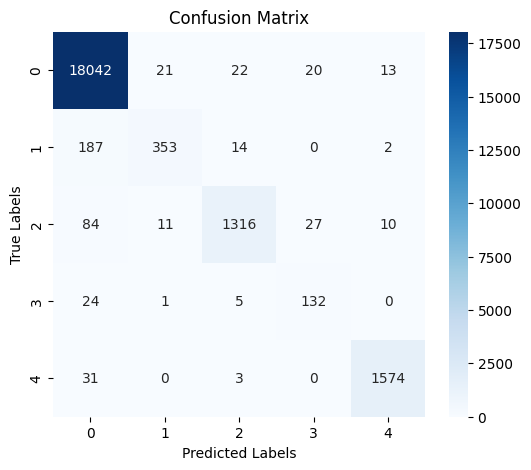

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18118
           1       0.91      0.63      0.75       556
           2       0.97      0.91      0.94      1448
           3       0.74      0.81      0.77       162
           4       0.98      0.98      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.92      0.87      0.89     21892
weighted avg       0.98      0.98      0.98     21892



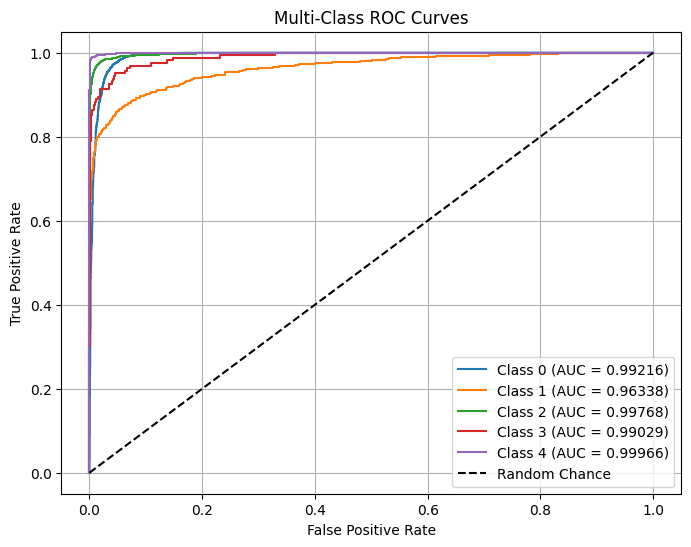

Macro AUC: 0.9886
Weighted AUC: 0.9923


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ✅ Predict probabilities
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=1)

# ✅ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# ✅ Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ ROC Curve (Multi-class)
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))  # One-hot encoding
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ✅ Plot all ROC Curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.5f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# ✅ Macro & Weighted AUC
macro_auc = roc_auc_score(y_test_bin, y_probs, average='macro', multi_class='ovr')
weighted_auc = roc_auc_score(y_test_bin, y_probs, average='weighted', multi_class='ovr')
print(f"Macro AUC: {macro_auc:.4f}")
print(f"Weighted AUC: {weighted_auc:.4f}")


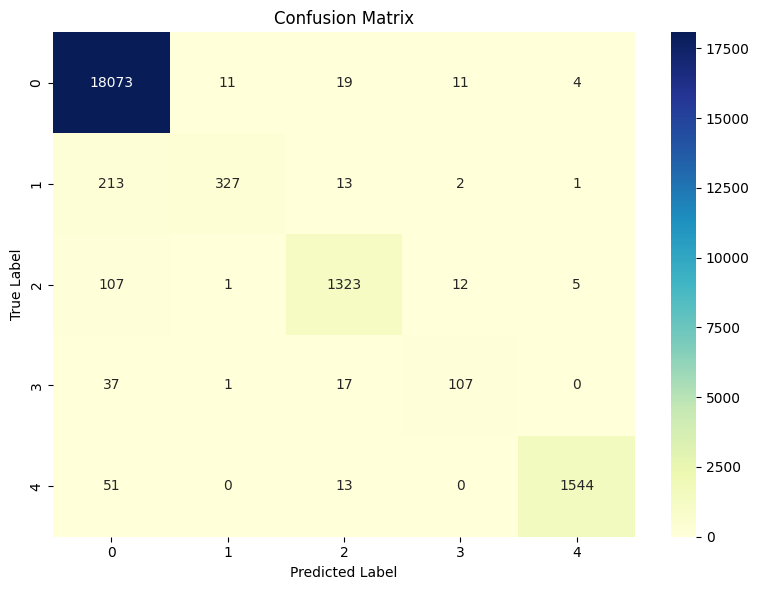

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=range(5), yticklabels=range(5))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


# **Visualisation of heartbeats**

In [ ]:
from google.colab import files
uploaded = files.upload()


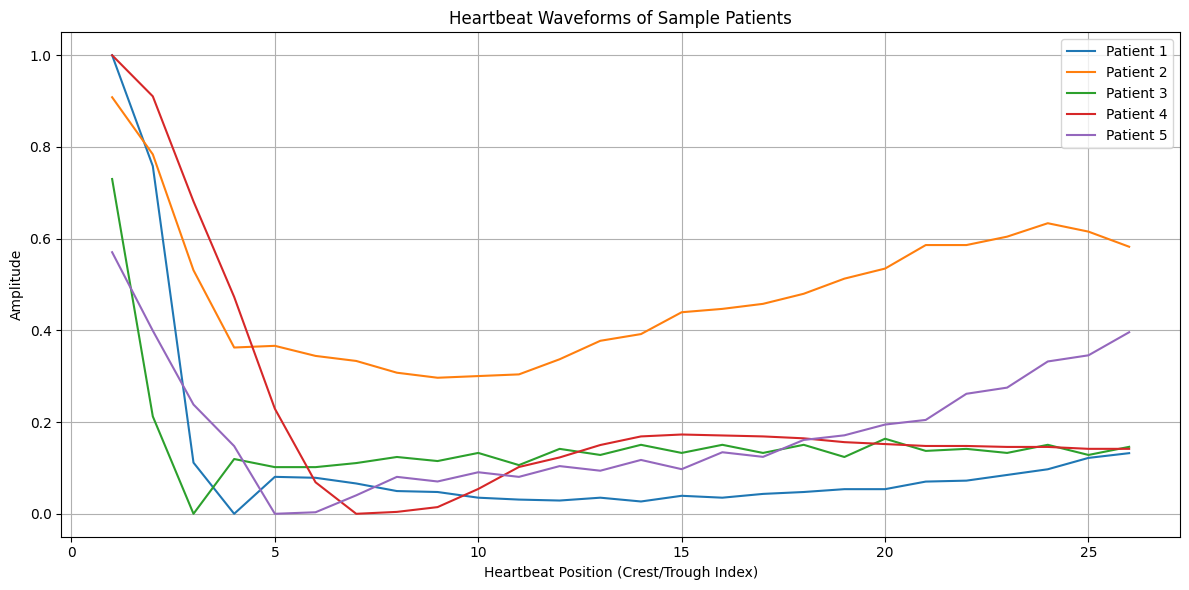

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV file
df = pd.read_csv('mitbih-test-final-2.csv', header=None)
#f = open("/content/drive/MyDrive/CS/file.txt", "w")


# Plot line graphs for a few example patients (rows)
plt.figure(figsize=(12, 6))

# Plot the first 5 patients (rows)
for i in range(5):
    plt.plot(df.columns[1:], df.iloc[i, 1:], label=f'Patient {int(df.iloc[i, 0])}')

plt.xlabel('Heartbeat Position (Crest/Trough Index)')
plt.ylabel('Amplitude')
plt.title('Heartbeat Waveforms of Sample Patients')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


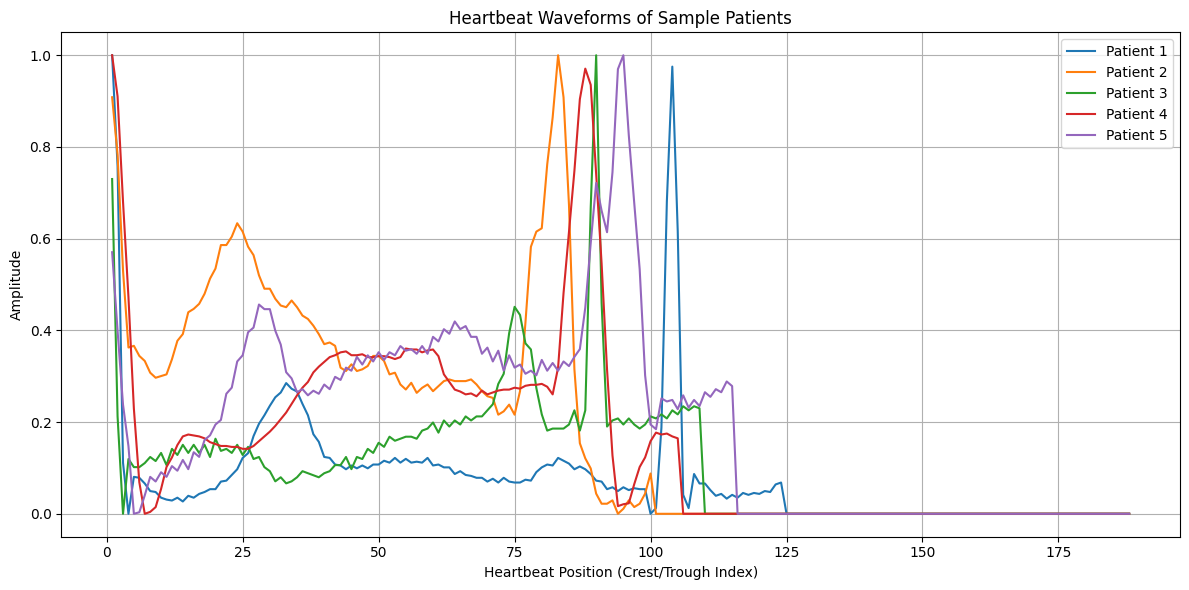

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV file
df = pd.read_csv('mitbih-test-final.csv', header=None)
#f = open("/content/drive/MyDrive/CS/file.txt", "w")


# Plot line graphs for a few example patients (rows)
plt.figure(figsize=(12, 6))

# Plot the first 5 patients (rows)
for i in range(5):
    plt.plot(df.columns[1:], df.iloc[i, 1:], label=f'Patient {int(df.iloc[i, 0])}')

plt.xlabel('Heartbeat Position (Crest/Trough Index)')
plt.ylabel('Amplitude')
plt.title('Heartbeat Waveforms of Sample Patients')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


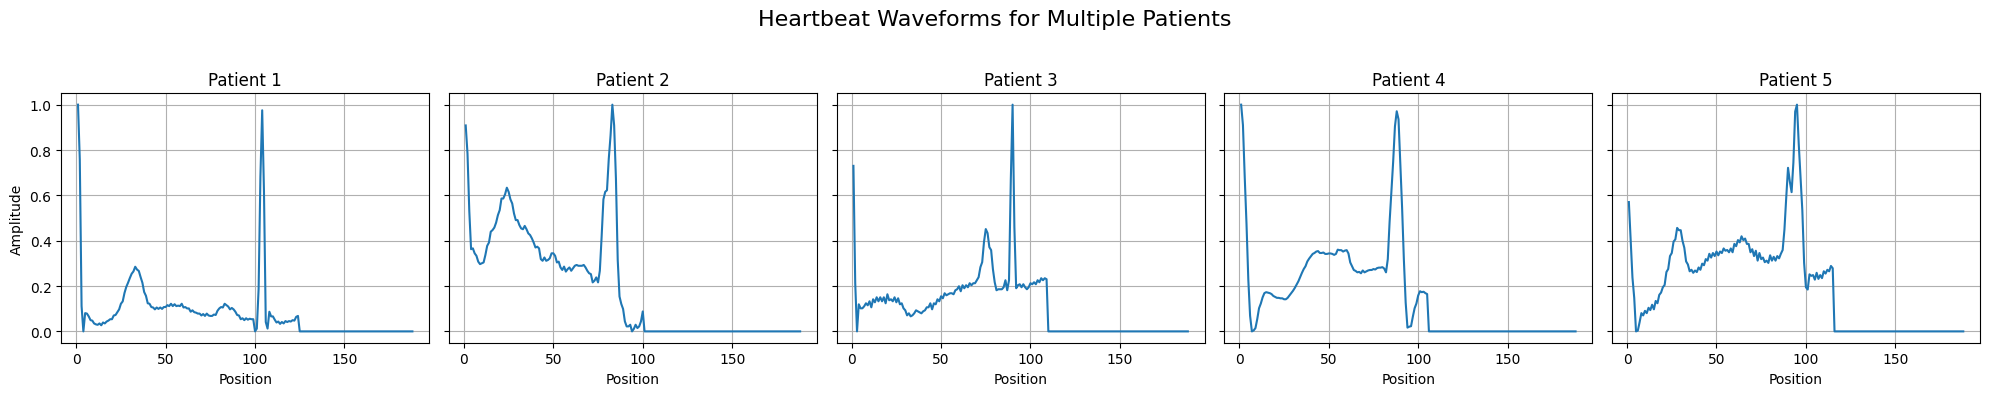

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV (assuming you've uploaded it in Colab)
df = pd.read_csv('mitbih-test-final.csv', header=None)

# Number of patients to plot (e.g., first 5)
num_patients = 5

# Create subplots (1 row, 5 columns)
fig, axes = plt.subplots(1, num_patients, figsize=(20, 4), sharey=True)

# Plot each patient's data in a separate subplot
for i in range(num_patients):
    axes[i].plot(range(1, df.shape[1]), df.iloc[i, 1:])
    axes[i].set_title(f'Patient {int(df.iloc[i, 0])}')
    axes[i].set_xlabel('Position')
    if i == 0:
        axes[i].set_ylabel('Amplitude')
    axes[i].grid(True)

plt.suptitle('Heartbeat Waveforms for Multiple Patients', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
